Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/retinal-disease-classification/versions/1
Train labels shape: (1920, 47)
Validation labels shape: (640, 47)
Test labels shape: (640, 47)
   ID  Disease_Risk  DR  ARMD  MH  DN  MYA  BRVO  TSLN  ERM  LS  MS  CSR  ODC  \
0   1             1   1     0   0   0    0     0     0    0   0   0    0    0   
1   2             1   1     0   0   0    0     0     0    0   0   0    0    0   
2   3             1   1     0   0   0    0     0     0    0   0   0    0    0   
3   4             1   0     0   1   0    0     0     0    0   0   0    0    1   
4   5             1   1     0   0   0    0     0     0    0   1   0    0    0   

   CRVO  TV  AH  ODP  ODE  ST  AION  PT  RT  RS  CRS  EDN  RPEC  MHL  RP  CWS  \
0     0   0   0    0    0   0     0   0   0   0    0    0     0    0   0    0   
1     0   0   0    0    0   0     0   0   0   0    0    0     0    0   0    0   
2     0   0   0    0    0   0     0   0   0   0    0    0     0    0

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - accuracy: 0.7534 - loss: 0.7853 - val_accuracy: 0.7906 - val_loss: 0.5368
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 302s 5s/step - accuracy: 0.7871 - loss: 0.5155 - val_accuracy: 0.7906 - val_loss: 0.4956
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 314s 5s/step - accuracy: 0.7988 - loss: 0.4866 - val_accuracy: 0.7906 - val_loss: 0.5195
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 328s 5s/step - accuracy: 0.8025 - loss: 0.4539 - val_accuracy: 0.7906 - val_loss: 0.4836
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 311s 5s/step - accuracy: 0.7964 - loss: 0.4522 - val_accuracy: 0.8062 - val_loss: 0.4599
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 317s 5s/step - accuracy: 0.7912 - loss: 0.4610 - val_accuracy: 0.7906 - val_loss: 0.4631
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 324s 5s/step - accuracy: 0.7884 - loss: 0.4620 - val_accuracy: 0.8078 - val_loss: 0.4744
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 321s 5s/step - accuracy: 0.8217 - loss: 0.4238 - val_accuracy: 0.8141 - v

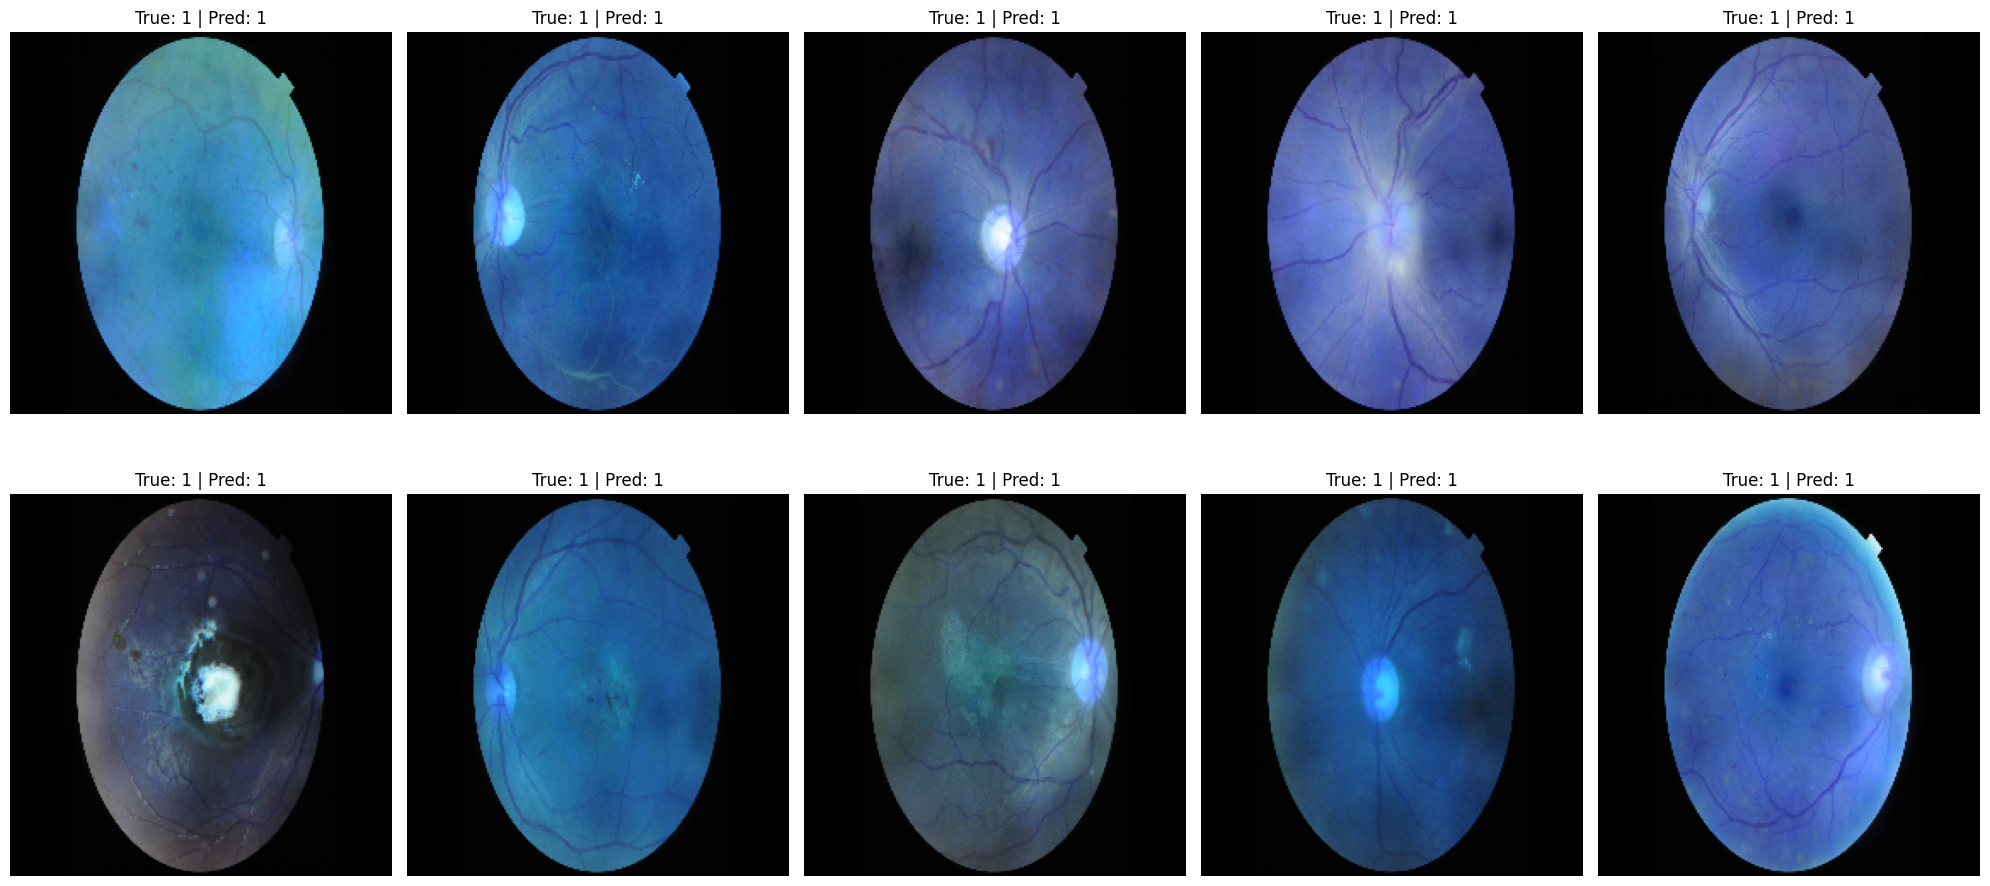

In [ ]:
# ===================== IMPORTS =====================
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# ===================== SETTINGS =====================
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# ===================== DOWNLOAD DATASET =====================
path = kagglehub.dataset_download("andrewmvd/retinal-disease-classification")
print("Path to dataset files:", path)

# Define directories
train_dir = os.path.join(path, "Training_Set", "Training_Set", "Training")
val_dir = os.path.join(path, "Evaluation_Set", "Evaluation_Set", "Validation")
test_dir = os.path.join(path, "Test_Set", "Test_Set", "Test")

train_labels_path = os.path.join(path, "Training_Set", "Training_Set", "RFMiD_Training_Labels.csv")
val_labels_path = os.path.join(path, "Evaluation_Set", "Evaluation_Set", "RFMiD_Validation_Labels.csv")
test_labels_path = os.path.join(path, "Test_Set", "Test_Set", "RFMiD_Testing_Labels.csv")

# ===================== LOAD LABELS =====================
train_labels = pd.read_csv(train_labels_path)
val_labels = pd.read_csv(val_labels_path)
test_labels = pd.read_csv(test_labels_path)

print("Train labels shape:", train_labels.shape)
print("Validation labels shape:", val_labels.shape)
print("Test labels shape:", test_labels.shape)
print(train_labels.head())

# ===================== EDA =====================
disease_counts = train_labels.iloc[:, 2:].sum().sort_values(ascending=False)
fig = px.bar(disease_counts, title="Disease Distribution in Training Set")
fig.show()

# ===================== IMAGE LOADING FUNCTION =====================
def load_images_and_labels(image_dir, labels_df):
    images, labels = [], []
    for index, row in labels_df.iterrows():
        image_path = os.path.join(image_dir, f"{row['ID']}.png")
        if os.path.exists(image_path):
            img = cv2.imread(image_path)
            img = cv2.resize(img, (224, 224))
            images.append(img)
            labels.append(row['Disease_Risk'])  # Assuming binary label
    return np.array(images), np.array(labels)

# ===================== LOAD DATA =====================
X_train, y_train = load_images_and_labels(train_dir, train_labels)
X_val, y_val = load_images_and_labels(val_dir, val_labels)
X_test, y_test = load_images_and_labels(test_dir, test_labels)

# ===================== NORMALIZATION =====================
X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0

# ===================== IMAGE AUGMENTATION =====================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ===================== MODEL =====================
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ===================== TRAIN MODEL =====================
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=5
)

# ===================== EVALUATION =====================
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(cm, text_auto=True, title="Confusion Matrix")
fig.show()

# ===================== PLOT HISTORY =====================
fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Train Accuracy'))
fig.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Val Accuracy'))
fig.update_layout(title='Accuracy over Epochs', xaxis_title='Epoch', yaxis_title='Accuracy')
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history['loss'], mode='lines', name='Train Loss'))
fig.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines', name='Val Loss'))
fig.update_layout(title='Loss over Epochs', xaxis_title='Epoch', yaxis_title='Loss')
fig.show()

# ===================== DISPLAY PREDICTIONS =====================
def display_samples(images, true_labels, pred_labels, sample_count=10):
    plt.figure(figsize=(20, 10))
    for i in range(sample_count):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.title(f"True: {true_labels[i]} | Pred: {pred_labels[i][0]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_samples(X_test, y_test, y_pred, sample_count=10)
